![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)


# DEDL - HDA Tutorial - access HydroLand

**Author**: EUMETSAT / UFZ <br>
**Copyright**: 2026 EUMETSAT <br>
**Licence**: MIT <br>
**Modified by**: Jeisson Leal

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b>
<li> For Data access : <a href="https://platform.destine.eu/"> DestinE user account and access to restricted datasets</a> </li>
<li> Helper modules <code>hda_http.py</code>, <code>hda_stac.py</code>, <code>hda_download.py</code> live in <code>example_tools/</code> at the repository root.</li>
</div>

### Import the relevant modules

In [1]:
import sys
from pathlib import Path

# Add example_tools/ to the module search path (one level up from example_apps/)
sys.path.insert(0, str(Path("..") / "example_tools"))

In [2]:
import glob
import json
from getpass import getpass

import xarray as xr
import destinelab as deauth

from hda_http import request_json
from hda_stac import extract_all_items
from hda_download import download_item_archive, download_item_assets

### Define some constants for the API URL


In [3]:
# Define the collection to be used
COLLECTION_ID = "EO.UFZ.DAT.HYDROLAND"

# Core API
HDA_API_URL = "https://hda.data.destination-earth.eu"

# STAC API
STAC_API_URL = f"{HDA_API_URL}/stac/v2"
COLLECTIONS_URL = f"{STAC_API_URL}/collections"
COLLECTION_BY_ID_URL = f"{COLLECTIONS_URL}/{COLLECTION_ID}"
COLLECTION_ITEMS_URL = f"{COLLECTIONS_URL}/{COLLECTION_ID}/items"
SEARCH_URL = f"{STAC_API_URL}/search"

# Request settings
REQUEST_TIMEOUT = 30    # seconds
REQUEST_RETRIES = 3
DOWNLOAD_CHUNK_SIZE = 1_048_576  # 1 MB

## Authenticate

In [4]:
DESP_USERNAME = input("Please input your DESP username or email: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

DEDL/DESP Access Token Obtained Successfully


### Discover data - Authenticated

Once authenticated, we can discover the collection.

In [5]:
collection_metadata = request_json(
    "GET",
    COLLECTION_BY_ID_URL,
    headers=auth_headers,
    timeout=REQUEST_TIMEOUT,
    retries=REQUEST_RETRIES,
)
print(json.dumps(collection_metadata, indent=4))

{
    "id": "EO.UFZ.DAT.HYDROLAND",
    "description": "This catalog contains results from Hydroland produced with the Mesoscale Hydrologic Model (mHM). mHM outputs were further processed to provide user-oriented indicators, including Soil Moisture, Aridity Index, and Discharge Indicators. The dataset also includes the original mHM outputs and additional figures documenting model validation and selected results.",
    "stac_version": "1.1.0",
    "links": [
        {
            "rel": "http://www.opengis.net/def/rel/ogc/1.0/queryables",
            "type": "application/schema+json",
            "href": "https://hda.data.destination-earth.eu/stac/v2/collections/EO.UFZ.DAT.HYDROLAND/queryables",
            "title": "Queryables"
        },
        {
            "rel": "items",
            "type": "application/geo+json",
            "href": "https://hda.data.destination-earth.eu/stac/v2/collections/EO.UFZ.DAT.HYDROLAND/items",
            "title": "Items"
        },
        {
           

## Search

Once a collection is selected, you can search for items that match the specified input filters and order the results.

Adjust `SEARCH_DATETIME`, `SEARCH_BBOX`, and `SEARCH_LIMIT` to narrow the results. The collection currrently covers IFS-NEMO **1990-01-01 to 2049-12-31**.

In [6]:
SEARCH_DATETIME = "2040-01-01T00:00:00Z/2040-01-31T00:00:00Z" # Select the wanted range
SEARCH_BBOX = [-180, -90, 180, 90]
SEARCH_LIMIT = 1
SEARCH_SORTBY = [{"field": "datetime", "direction": "desc"}]

BODY = {
    "collections": [COLLECTION_ID],
    "datetime": SEARCH_DATETIME,
    "bbox": SEARCH_BBOX,
    "sortby": SEARCH_SORTBY,
    "limit": SEARCH_LIMIT,
}

search_json = request_json(
    "POST",
    SEARCH_URL,
    headers=auth_headers,
    json_body=BODY,
    timeout=REQUEST_TIMEOUT,
    retries=REQUEST_RETRIES,
)
print(json.dumps(search_json, indent=4))

{
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "assets": {
                "2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc": {
                    "href": "https://hda-download.eumetsat.data.destination-earth.eu/data/internal_fdp/EO.UFZ.DAT.HYDROLAND/EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm/2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc",
                    "type": "application/netcdf",
                    "title": "2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc",
                    "roles": [
                        "data"
                    ],
                    "alternate": {
                        "origin": {
                            "href": "https://s3.central.data.destination-earth.eu/usergenerated-eo.ufz.dat.hydroland/data/2040/01/EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP

## Download - individual assets (recommended)

Downloads each `.nc` file individually from S3 signed URLs — faster than the zip archive approach below.

In [7]:
download_item_assets(
    search_json=search_json,
    collection_id=COLLECTION_ID,
    auth_headers=auth_headers,
    request_timeout=REQUEST_TIMEOUT,
    chunk_size=DOWNLOAD_CHUNK_SIZE,
    existing_policy="skip",
)

Found 1 items containing 1 assets.


Overall:   0%|          | 0/1 [00:00<?, ?it/s]


Item: EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm


2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc:   0%|          | 0.00/30.8G [00:00<?, ?B/s]


Download complete
  Successful : 1
  Failed     : 0
  Skipped    : 0


{'total': 1, 'successful': 1, 'failed': 0, 'skipped': 0}

## Download - item archive via downloadLink (optional)

Downloads the complete item as a `.zip` archive. Use this if you want everything in a single file.

In [9]:
items = extract_all_items(search_json)

for item in items:
    download_url = item.get("assets", {}).get("downloadLink", {}).get("href")
    if not download_url:
        raise ValueError("Search result does not include assets.downloadLink.href")

    item_id = item.get("id")
    if not item_id:
        raise ValueError("Search result does not include item id")

    print("Download URL:", download_url)
    print("Item ID:", item_id)

    filename = download_item_archive(
        download_url=download_url,
        item_id=item_id,
        headers=auth_headers,
        timeout=REQUEST_TIMEOUT,
        chunk_size=DOWNLOAD_CHUNK_SIZE,
        existing_policy="skip",
    )
    print(f"Download successful! File saved as: {filename}")

Download URL: https://hda-download.eumetsat.data.destination-earth.eu/data/internal_fdp/EO.UFZ.DAT.HYDROLAND/EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm/downloadLink
Item ID: EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm
Skipping existing archive: EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm.zip
Download successful! File saved as: EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm.zip


# Display the downloaded file

The downloaded NetCDF files can be opened directly with xarray.

In [10]:
nc_files = glob.glob(f"{COLLECTION_ID}/**/*.nc", recursive=True)
if nc_files:
    local_file = nc_files[0]
    print(f"Opening: {local_file}")
    ds = xr.open_dataset(local_file)
    print(ds)
else:
    print("No .nc files found. Run the download cells above first.")

Opening: EO.UFZ.DAT.HYDROLAND/EO.UFZ.DAT.HYDROLAND_20400101T000000_20400131T230000__IFS-NEMO__SSP3-7.0__generation-2__projections__realization-1__mrm/2040_01_01_T00_00_to_2040_01_31_T23_00_mRM_Fluxes_States.nc
<xarray.Dataset> Size: 120GB
Dimensions:  (lon: 7200, lat: 2800, time: 744)
Coordinates:
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat      (lat) float64 22kB 83.97 83.92 83.88 83.82 ... -55.88 -55.93 -55.98
  * time     (time) datetime64[ns] 6kB 2040-01-01 ... 2040-01-31T23:00:00
Data variables:
    Qrouted  (time, lat, lon) float64 120GB ...
Attributes: (12/22)
    project:            Climate DT project
    setup_description:  model run for Climate DT project
    simulation_type:    simulation
    Conventions:        tbd
    contact:            Stephan Thober (email: stephan.thober@ufz.de
    mRM_details:        Helmholtz Center for Environmental Research - UFZ, De...
    ...                 ...
    class:              d1
    realization:   

## Plot the first time step

Zoomed-in map (western Europe by default -- edit `LON_MIN`/`LON_MAX`/`LAT_MIN`/`LAT_MAX`
in the cell below) of the first time step of `Qrouted` (falls back to the first
`lat`/`lon` variable if not present). The inset shows where the zoom sits on the globe.


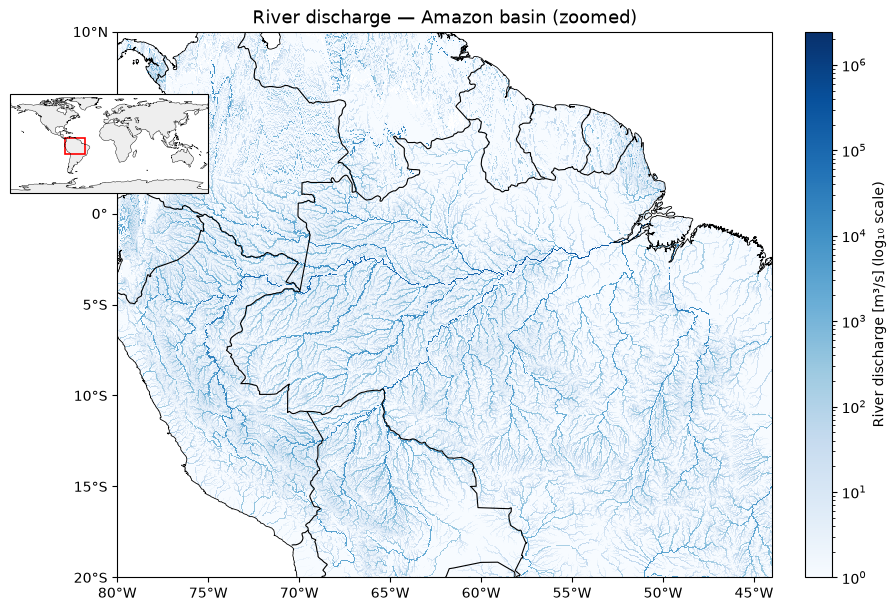

In [20]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# Zoom to western Europe -- edit these to look at a different region.
LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -10, 20, 36, 60

var_name = "Qrouted" if "Qrouted" in ds.data_vars else list(ds.data_vars)[0]
da0 = ds[var_name].isel(time=0) if "time" in ds[var_name].dims else ds[var_name]
timestamp = str(da0.time.values)[:16].replace("T", " ") if "time" in da0.coords else ""

# Crop before plotting so a global, high-resolution grid still renders fast.
lat_slice = slice(LAT_MAX, LAT_MIN) if da0.lat[0] > da0.lat[-1] else slice(LAT_MIN, LAT_MAX)
field = da0.sel(lat=lat_slice, lon=slice(LON_MIN, LON_MAX)).where(lambda x: x > 0)

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": proj}, constrained_layout=True)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=proj)

mesh = field.plot.pcolormesh(
    ax=ax, transform=proj, cmap="Blues",
    norm=colors.LogNorm(vmin=1, vmax=float(field.max())),
    add_colorbar=False,
)
ax.coastlines(resolution="10m", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.set_xticks(np.arange(LON_MIN, LON_MAX + 1, 5), crs=proj)
ax.set_yticks(np.arange(LAT_MIN, LAT_MAX + 1, 5), crs=proj)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(
    f"River discharge (HydroLand) \u2014 IFS-FESOM projection\n{timestamp} UTC",
    fontsize=13,
)

cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("River discharge [m\u00b3/s] (log\u2081\u2080 scale)")

# Small locator globe so it's clear this is a zoom-in, not the whole domain.
axins = fig.add_axes([0.02, 0.66, 0.22, 0.22], projection=proj)
axins.set_global()
axins.add_feature(cfeature.LAND, facecolor="#eee", zorder=0)
axins.coastlines(resolution="110m", linewidth=0.3)
axins.add_patch(mpatches.Rectangle(
    (LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
    edgecolor="red", facecolor="none", linewidth=1.2, transform=proj,
))
axins.set_xticks([])
axins.set_yticks([])

plt.show()